<a href="https://colab.research.google.com/github/Jules-Vatel/SSI_SPRING/blob/main/SSI_SPRING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [233]:
import importlib.util
if (importlib.util.find_spec("girth") == None):
  !pip install girth
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy as sp
import girth



### Data Loading and Initial Setup
This section imports necessary libraries and loads the dataset from a specified URL into a pandas DataFrame. It also includes the setup for `FactorAnalyzer`, which is used later for dimensional reduction.

In [234]:

#url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/SSI_2026_pilot.csv"
#url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/SSI_2026_initial.csv"
url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/SSI_2026_final.csv"
df = pd.read_csv(url)

In [235]:
#function for seven point party strength
def seven_pt_pid(row):
  # use follow up questions to determine strength
  party = row['Q-PartyAffiliation']
  strength = row['Q-PolarAffiliation']
  lean = row['Q-MiddleAffiliation']
  # from 1 = strong democrat to 7 = strong republican
  if (party=='Democrat'):
      return 1 if strength == 'Strong' else 2
  elif(party=='Republican'):
      return 7 if strength == 'Strong' else 6
  elif(party in ['Independent','No Preference','Other Party (Please Specify)']):
      if (lean=='Closer to Democratic Party'):
          return 3
      elif (lean=='Closer to Republican Party'):
          return 5
      elif(lean=='Neither'):
          return 4
  return np.nan


In [236]:
# function that just gets party id for leaners too
def get_party(row):
    pa = row['Q-PartyAffiliation']
    # just return Democrat, Republican, or Independent
    if(pa=='Democrat'):
        return 'Democrat'
    elif(pa=='Republican'):
        return 'Republican'
    elif(pa in ['Independent','No Preference','Other Party (Please Specify)']):
        ma = row.get('Q-MiddleAffiliation', np.nan)
        if(ma=='Closer to Democratic Party'):
            return 'Democrat'
        elif(ma=='Closer to Republican Party'):
            return 'Republican'
    return np.nan



In [237]:
# helper to get party category
def get_party_group(row):
    party = row['Q-PartyAffiliation']
    if party == 'Democrat':
        return 'Democrat'
    if party == 'Republican':
        return 'Republican'
    if party in ['Independent', 'No Preference', 'Other Party (Please Specify)']:
        return 'Independent'
    return np.nan

In [238]:
# map comfort scale responses from 1-7 value
comfort_map = {
    'Very uncomfortable': 7, 'Uncomfortable': 6, 'Somewhat uncomfortable': 5,
    'Neither comfortable nor uncomfortable': 4, 'Somewhat comfortable': 3,
    'Comfortable': 2, 'Very comfortable': 1, 'Very Comfortable': 1
}

#same thing as comfort map but relates to the relection question so it can be mapped to variables
reelect_map = {
    'Very unlikely': 1, 'Unlikely': 2, 'Somewhat unlikely': 3,
    'Neither likely nor unlikely': 4, 'Somewhat likely': 5,
    'Likely': 6, 'Very likely': 7
}

# store treatment labels
treatment_labels = {
    'T1': 'In-party electoral',
    'T2': 'In-party democracy',
    'T3': 'In-party policy',
    'T4': 'Out-party electoral',
    'T5': 'Out-party democracy',
    'T6': 'Out-party policy',
}


tolerance_map = {
    'Not at all important': 7,
    'Unimportant': 6,
    'Somewhat unimportant': 5,
    'Neither important nor unimportant': 4,
    'Somewhat important': 3,
    'Important': 2,
    'Very important': 1
}

PID_map = {1:'Strong partisan',
           7:'Strong partisan',
           2:'Weak partisan',
           6:'Weak partisan',
           3:'Leaner',
           5:'Leaner',
           4:'Pure independent'}



def grm_eap(data, discrimination, difficulty, n_quad=61, bounds=(-4, 4)):
    #EAP ability estimation for Graded Response Model
    #girth does not natively support polytomous estimation only dichotomous estiamation
    #since there are 7 possible values for our data this function is designed to implement
    #the polytomous estimation required to effectively analyze the data.
    n_items, n_persons = data.shape
    theta_grid = np.linspace(bounds[0], bounds[1], n_quad)
    prior = sp.stats.norm.pdf(theta_grid)
    prior /= prior.sum()
    thetas = np.zeros(n_persons)
    for p in range(n_persons):
      log_lik = np.zeros(n_quad)
      for i in range(n_items):
        resp = data[i, p]
        a = discrimination[i]
        d = difficulty[i]
        n_cat = len(d) + 1
        cum_probs = np.zeros((n_quad, n_cat + 1))
        cum_probs[:, 0] = 1.0
        cum_probs[:, n_cat] = 0.0
        for k in range(len(d)):
          cum_probs[:, k+1] = sp.special.expit(a * (theta_grid - d[k]))
        cat_probs = np.clip(cum_probs[:, :-1] - cum_probs[:, 1:], 1e-10, 1.0)
        log_lik += np.log(cat_probs[:, resp])
      posterior = np.exp(log_lik) * prior
      posterior /= posterior.sum()
      thetas[p] = np.sum(theta_grid * posterior)
    return thetas

### `DATA_ANALYSIS` Class
This class captures the entire data analysis pipeline. It processes raw survey data, calculates key outcome variables like Affective Polarization (`APpost`) and Tolerance for Backsliding (`TB`), runs OLS regression models, performs F-tests for various research questions, and includes methods for plotting results. It also handles heterogeneity of treatment effects (HTE) by party group.

In [239]:
# run OLS regression and return model
def run_ols(formula,data):
  return sm.OLS.from_formula(formula,data).fit(cov_type='HC1')

# calculates linear estimate and standard error from a statsmodels regression model
# return estimate, standard error, and CI
def _linear_estimate(model, weights):
  params = model.params
  cov = model.cov_params()
  estimate = sum(weight * params[name] for name, weight in weights.items())
  variance = 0
  # get standard error
  for left_name, left_weight in weights.items():
    for right_name, right_weight in weights.items():
      variance += left_weight * right_weight * cov.loc[left_name, right_name]
  se = np.sqrt(variance)
  return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se

class DATA_ANALYSIS:
  """
  Class to store data processing, statistical analysis, and visualization for political survey data.
  Makes plots and handles analysis and regression models.
  """

  # Initializes object, processes the raw DataFrame, and runs initial OLS models and F-tests given maps
  def __init__(self,df=df,cmap=comfort_map,rmap=reelect_map):
    df = df[~df['Treat_Party'].str.contains('ImportId',na=False)].copy()
    # extract important values and rename
    df['Feeling_ThermR'] = pd.to_numeric(df['Q-FeelingTherm_1'],errors='coerce')
    df['Feeling_ThermD'] = pd.to_numeric(df['Q-FeelingTherm_2'],errors='coerce')
    #note changed Q-FeelingThermR_1 to Q-FeelingTherm_1 and changed Q-FeelingThermD_1 to Q-FeelingTherm_2 based on updated data
    df['PA']=df.apply(seven_pt_pid,axis=1)
    df['PID_strength']=df['PA'].map(PID_map)
    df['Party'] = df.apply(get_party, axis=1)
    df['PartyGroup'] = df.apply(get_party_group, axis=1)

    # plan defines APpre as |FTRep - FTDem| for every respondent.
    df['TBpre'] = df['Q-AffPolarization'].map(tolerance_map)
    df['APpre'] = (df['Feeling_ThermR']-df['Feeling_ThermD']).abs()
    for col in ['Q-InLawDist', 'Q-CloseFriendDist', 'Q-Social Distance 3']:
      df[col + '_n'] = df[col].map(cmap)
    #for Lin Estimator, de-meaning data and standardizing w std 1
    df['APpre_dm']=(df['APpre']-df['APpre'].mean())/ df['APpre'].std()
    df['TBpre_dm'] = (df['TBpre']-df['TBpre'].mean())/df['TBpre'].std()

    # additive social-distance index from the plan: sum of three 1-7 items divided by 21.
    # df['APpost'] = df[['Q-InLawDist_n', 'Q-CloseFriendDist_n','Q-Social Distance 3_n']].sum(axis=1, min_count=3) / 21
    ap_items = ['Q-InLawDist_n', 'Q-CloseFriendDist_n', 'Q-Social Distance 3_n']
    # drop null rows
    ap_valid_data = df[ap_items].dropna()
    grm_data = ap_valid_data.to_numpy(dtype=int)
    grm_data=grm_data.T
    #note had to subtract 1 because this model requires data to be on scale of 0-6 as for
    # array with 7 elements scale of 1-7 would give index out of bounds on array element 7
    grm_data-=1
    params = girth.grm_mml(grm_data)
    thet = grm_eap(grm_data,params['Discrimination'],params['Difficulty'])
    raw = pd.Series(thet,index=ap_valid_data.index)
    df['APpost']=np.nan
    df.loc[raw.index,'APpost']=raw
    df['APpost'] = (df['APpost']-df['APpost'].mean())/df['APpost'].std()
    # get values for each of 6 framing treatment combinations
    df['TB'] = df['Q-ReElection'].map(rmap)
    df['TB'] = (df['TB'] - df['TB'].mean())/df['TB'].std()
    df['T1'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T2'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T3'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Policy')).astype(int)
    df['T4'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T5'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T6'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Policy')).astype(int)

    analysis_vars = ['APpost','TB','APpre']
    full = df.dropna(subset=analysis_vars).copy()
    # run initial regressions
    AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre_dm + T1:APpre_dm + T2:APpre_dm + T3:APpre_dm + T4:APpre_dm + T5:APpre_dm + T6:APpre_dm', full)
    TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + TBpre_dm + T1:TBpre_dm + T2:TBpre_dm + T3:TBpre_dm + T4:TBpre_dm + T5:TBpre_dm + T6:TBpre_dm', full)
    self.df = df
    self.full = full
    self.AP = AP
    self.TB = TB
    # run several tests with different combination of coefficients
    self.t1_AP=t1_AP = AP.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0')
    self.t1_TB=t1_TB = TB.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0')
    self.t2_AP=t2_AP = AP.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3')
    self.t2_TB=t2_TB = TB.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3')
    self.t3_AP_EP=t3_AP_EP = AP.t_test('(T1 + T4)/2 = (T3 + T6)/2')
    self.t3_AP_DP=t3_AP_DP=AP.t_test('(T2 + T5)/2 = (T3 + T6)/2')
    self.t3_AP_ED=t3_AP_ED = AP.t_test('(T1 + T4)/2 = (T2 + T5)/2')
    self.t3_TB_EP=t3_TB_EP = TB.t_test('(T1 + T4)/2 = (T3 + T6)/2')
    self.t3_TB_DP=t3_TB_DP = TB.t_test('(T2 + T5)/2 = (T3 + T6)/2')
    self.t3_TB_ED=t3_TB_ED = TB.t_test('(T1 + T4)/2 = (T2 + T5)/2')
    self.f4_AP=f4_AP = AP.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.f4_TB=f4_TB = TB.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.model=[AP,TB]
    self.ttests=[[t1_AP,t1_TB],[t2_AP,t2_TB],[t3_AP_EP,t3_TB_EP,t3_AP_DP,t3_TB_DP,t3_AP_ED,t3_TB_ED]]
    self.ftests=[f4_AP,f4_TB]
    self.hte_models = self._run_split_models(full, 'PartyGroup')
    self.inparty_models = self._run_split_models(full, 'InParty')
    self.strength_models = self._run_split_models(full, 'PID_strength')
    self.action_models = self._run_split_models(full, 'Q-DemThreat')
    self.samples_full = len(full)


  def _run_split_models(self,full,split_var):
    models = {}
    for group in full[split_var].dropna().unique():
        group_data = full[full[split_var]==group].copy()
        if(len(group_data)!=0):
          AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre_dm + T1:APpre_dm + T2:APpre_dm + T3:APpre_dm + T4:APpre_dm + T5:APpre_dm + T6:APpre_dm', group_data)
          TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + TBpre_dm + T1:TBpre_dm + T2:TBpre_dm + T3:TBpre_dm + T4:TBpre_dm + T5:TBpre_dm + T6:TBpre_dm', group_data)
          models[group] = {'n': len(group_data),
          'AP': AP,
          'TB': TB,
          'Any treatment (AP)': AP.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0'),
          'Any treatment (TB)': TB.t_test('(T1 + T2 + T3 + T4 + T5 + T6)/6 = 0'),
          'In vs Out party (AP)': AP.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3'),
          'In vs Out party (TB)': TB.t_test('(T1 + T2 + T3)/3 = (T4 + T5 + T6)/3'),}
    return models


  def print_summary_all(self):
    """
    Print summary tables for both affective polarization and tolerance for backsliding models.
    """
    labels=["Affective Polarization","Tolerance for Backsliding"]
    model = self.model
    for i in range(len(model)):
      print(f"Model Results ({labels[i]})")
      print(model[i].summary(),"\n")

  def print_summary_single(self,id):
    """
    Print summary table for a single specified model (AP or TB).
    """
    model = self.model

    n = None
    labels=["Affective Polarization","Tolerance for Backsliding"]
    if(id.upper()=="AP"):
      n = 0
    else:
      n = 1
    print(f"Results ({labels[n]})")
    print(model[n].summary(),"\n")

  def print_t_tests_all(self):
    """
    Prints the results of all predefined t-tests for the research questions.
    """
    ttests = self.ttests
    labels = [["RQ1: Any treatment (AP)","RQ1: Any treatment (TB)"],
      ["RQ2: In vs Out party (AP)","RQ2: In vs Out party (TB)"],
      ["RQ3: Electoral vs Policy (AP)","RQ3: Electoral vs Policy (TB)","RQ3: Democracy vs Policy (AP)","RQ3: Democracy vs Policy (TB)","RQ3: Electoral vs Democracy (AP)","RQ3: Electoral vs Democracy (TB)"]]
    for i in range(len(ttests)):
      for j in range(len(ttests[i])):
        print(f"{labels[i][j]} {ttests[i][j]}")

  def print_f_tests(self):
    """
    Prints the results of all predefined F-tests for the research questions.
    """
    ftests = self.ftests
    label = ["RQ4: Framing x Party (AP)","RQ4: Framing x Party (TB)"]
    for i in range(len(ftests)):
        print(f"{label[i]} {ftests[i]}")


  def _get_model(self, outcome):
    """
    Helper function to retrieve the model and title based on the outcome type.
    """
    if outcome.upper() == 'AP':
      return self.AP, 'Affective Polarization'
    if outcome.upper() == 'TB':
      return self.TB, 'Tolerance for Backsliding'
    raise ValueError("outcome must be 'AP' or 'TB'")

  def _coefficient_table(self, model):
    """
    Get DataFrame of treatment coefficients and their confidence intervals given a model.
    """
    ci = model.conf_int(alpha=0.05)
    rows = []
    for term in treatment_labels:
      rows.append({
          'term': term,
          'label': treatment_labels[term],
          'estimate': model.params[term],
          'lower': ci.loc[term, 0],
          'upper': ci.loc[term, 1],
      })
    return pd.DataFrame(rows)

  def plot_treatment_effects(self, outcome='AP', ax=None, save_path=None, show=True):
    """
    Plot treatment effects with confidence intervals for a specified outcome.

    Args:
      outcome (str): 'AP' for Affective Polarization or 'TB' for Tolerance for Backsliding.
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    model, title = self._get_model(outcome)
    plot_data = self._coefficient_table(model)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.8))
    else:
        fig = ax.figure
    y = np.arange(len(plot_data))
    xerr = [plot_data['estimate'] - plot_data['lower'], plot_data['upper'] - plot_data['estimate']]
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['label'])
    ax.invert_yaxis()
    ax.set_xlabel('Treatment effect relative to control')
    ax.set_title(f'{title}: treatment-cell coefficients')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    print("\n\n\n")
    return fig,ax

  def graph_delta_ap(self, ax=None, save_path=None, show=True):
    """
    Helper to plot treatment effects for affective polarization.

    Args:
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    return self.plot_treatment_effects(outcome='AP', ax=ax, save_path=save_path, show=show)

  def graph_delta_tb(self, ax=None, save_path=None, show=True):
    """
    Helper to plot treatment effects for Tolerance for Backsliding.

    Args:
      ax (matplotlib.axes.Axes, optional): A pre-existing axes object to plot on. Defaults to None.
      save_path (str, optional): File path to save the plot. Defaults to None.
      show (bool): Whether to display the plot. Defaults to True.

    Returns:
      tuple: A tuple containing the matplotlib Figure and Axes objects.
    """
    return self.plot_treatment_effects(outcome='TB', ax=ax, save_path=save_path, show=show)


  def plot_hte_in_vs_out(self, outcome='AP', attr='hte_models', ax=None, save_path=None, show=True):
    outcome_key = outcome.upper()
    if outcome_key not in ['AP', 'TB']:
        raise ValueError("outcome must be 'AP' or 'TB'")
    rows = []
    weights = {'T1': 1/3, 'T2': 1/3, 'T3': 1/3, 'T4': -1/3, 'T5': -1/3, 'T6': -1/3}
    for group, results in getattr(self, attr).items():
        estimate, se, lower, upper = _linear_estimate(results[outcome_key], weights)
        rows.append({'group': str(group), 'estimate': estimate, 'se': se, 'lower': lower, 'upper': upper})
    plot_data = pd.DataFrame(rows)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3.8))
    else:
        fig = ax.figure
    y = np.arange(len(plot_data))
    xerr = [plot_data['estimate'] - plot_data['lower'], plot_data['upper'] - plot_data['estimate']]
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['group'])
    ax.invert_yaxis()
    ax.set_xlabel('Average in-party effect minus average out-party effect')
    ax.set_title(f'{self._get_model(outcome_key)[1]}: HTE ({attr})')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    print("\n\n\n")
    return fig, ax

  def print_descriptives(self):
    full = self.full
    print("=== CELL SIZES ===")
    print(pd.crosstab(full['Treat_Party'], full['Treat_Frame'], margins=True))
    print("\n=== ACTION SELECTED AS MOST SEVERE ===")
    print(full['Q-DemThreat'].value_counts())
    print("\n=== ACTION × TREATMENT (balance check) ===")
    print(pd.crosstab(full['Q-DemThreat'], full['Treat_Party'], normalize='columns').round(3))
    print("\n=== PRE-TREATMENT MEANS BY CONDITION ===")
    print(full.groupby('Treat_Party')[['APpre', 'TBpre']].mean().round(3))
    print("\n=== PARTY ID DISTRIBUTION ===")
    print(full['PartyGroup'].value_counts())
    print("\n=== PID STRENGTH DISTRIBUTION ===")
    print(full['PID_strength'].value_counts())

  def print_all_hte(self):
      cats = [('Self-Reported Party', 'hte_models'),('Assigned In-Party', 'inparty_models'),('PID Strength', 'strength_models'),('Backsliding Action', 'action_models')]
      for name, attr in cats:
          print(f"\n{'='*60}\nHTE by {name}\n{'='*60}")
          for group, r in getattr(self, attr).items():
              print(f"\n  {group} (n={r['n']})")
              for k in ['Any treatment (AP)', 'Any treatment (TB)',
                      'In vs Out party (AP)', 'In vs Out party (TB)']:
                  t = r[k]
                  print(f"    {k}: effect={float(t.effect):.3f}, p={float(t.pvalue):.3f}")

  def plot_action_models_bar(self, outcome='TB', save_path=None):
    outcome_key = outcome.upper()
    rows = []
    weights = {'T1': 1/3, 'T2': 1/3, 'T3': 1/3, 'T4': -1/3, 'T5': -1/3, 'T6': -1/3}
    for action, results in self.action_models.items():
        estimate, se, lower, upper = _linear_estimate(results[outcome_key], weights)
        rows.append({'action': str(action), 'estimate': estimate, 'se': se})
    plot_data = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(plot_data))
    # Bar chart
    bars = ax.bar(x, plot_data['estimate'], yerr=plot_data['se']*1.96, capsize=5, color='skyblue', edgecolor='black')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_xticks(x)
    # Wrap text for x-axis labels so they fit
    import textwrap
    ax.set_xticklabels([textwrap.fill(val, 15) for val in plot_data['action']])
    # Explicit Axis Labels per Professor's notes
    ax.set_ylabel(f'Standard Deviations (Control = 0)')
    ax.set_xlabel('Backsliding Action Selected as Most Severe')
    ax.set_title(f'In-Party vs. Out-Party Treatment Effect on {outcome_key} by Severe Action')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()



In [240]:

  # testing with made up data
  results = DATA_ANALYSIS()


  #model summaries
  results.print_summary_all()





Model Results (Affective Polarization)
                            OLS Regression Results                            
Dep. Variable:                 APpost   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     60.27
Date:                Mon, 18 May 2026   Prob (F-statistic):          6.21e-139
Time:                        04:20:06   Log-Likelihood:                -3498.9
No. Observations:                2720   AIC:                             7026.
Df Residuals:                    2706   BIC:                             7108.
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept  

### Executing the Analysis
This cell instantiates the `DATA_ANALYSIS` class, triggering the data processing, model fitting, and statistical tests. It then prints summary tables for the OLS models, F-test results, and HTE results. Finally, it generates and displays plots visualizing the treatment effects on Affective Polarization and Tolerance for Backsliding, as well as HTE by party group.

In [241]:
#T tests
results.print_t_tests_all()

RQ1: Any treatment (AP)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.0673      0.040      1.704      0.088      -0.010       0.145
RQ1: Any treatment (TB)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.6003      0.037    -16.221      0.000      -0.673      -0.528
RQ2: In vs Out party (AP)                              Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.1810      0.039     -4.673      0.000   

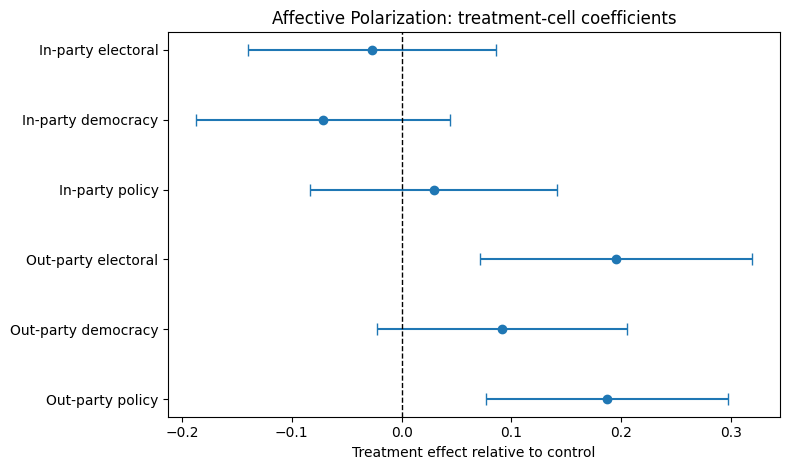

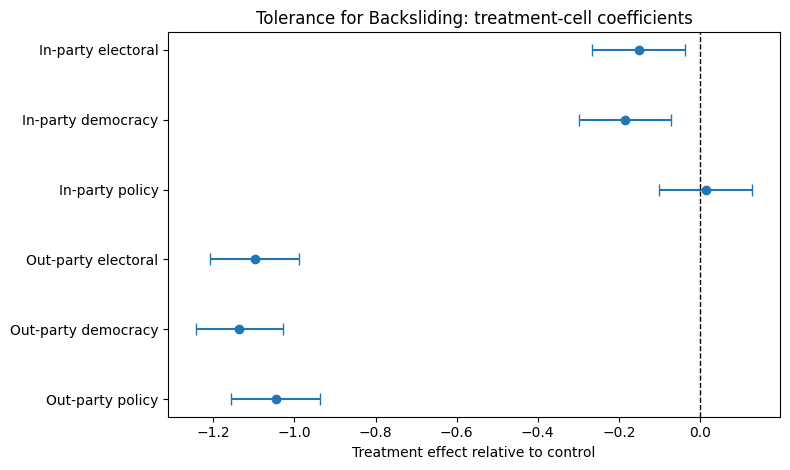

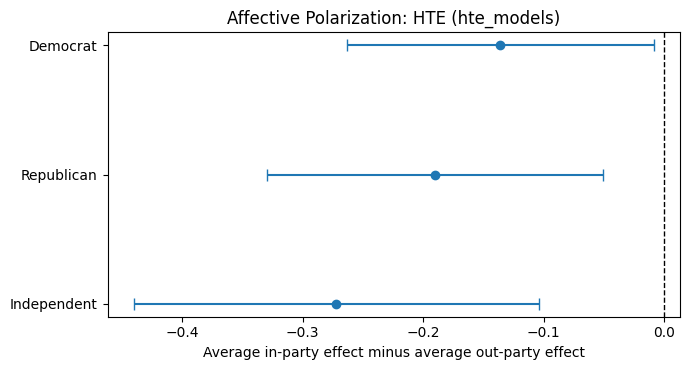

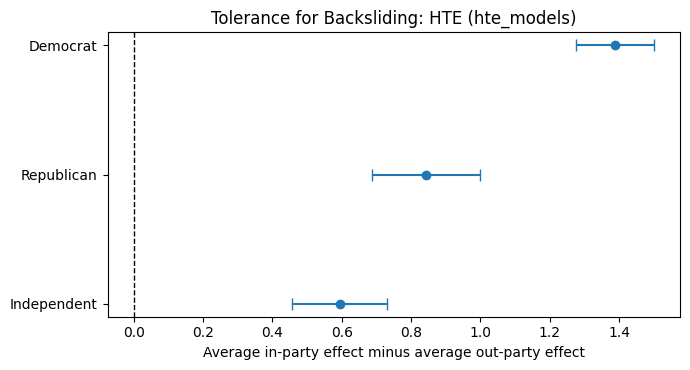

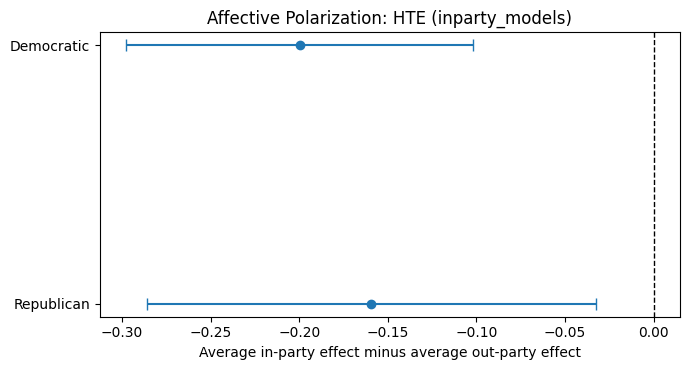

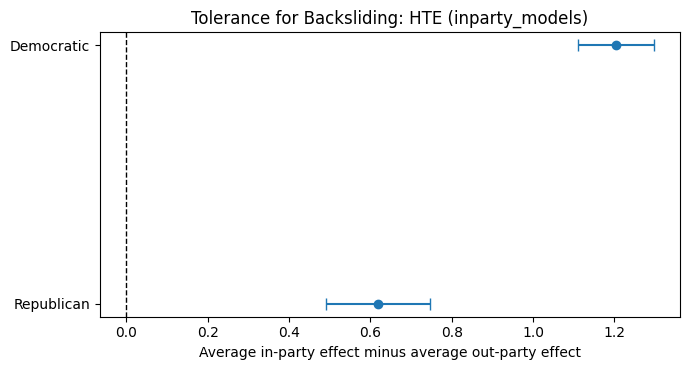

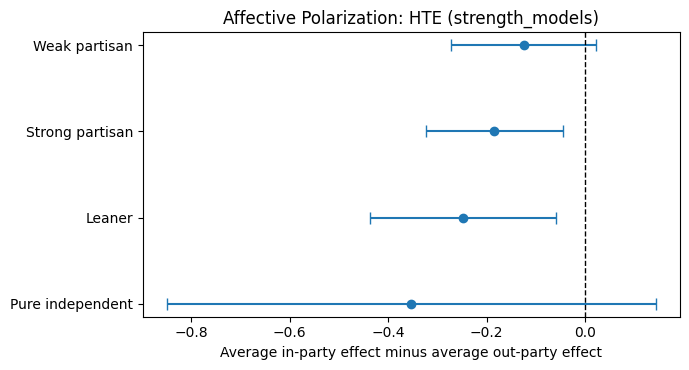

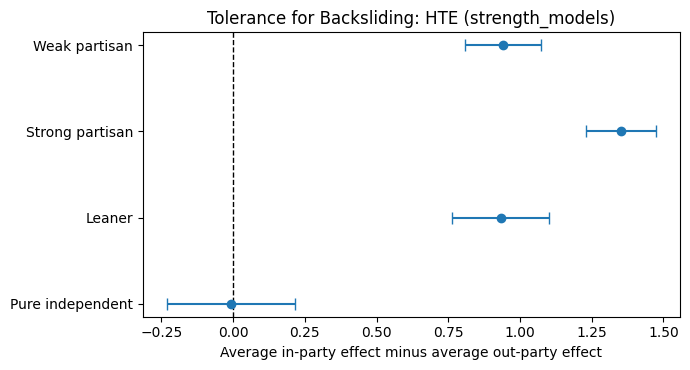

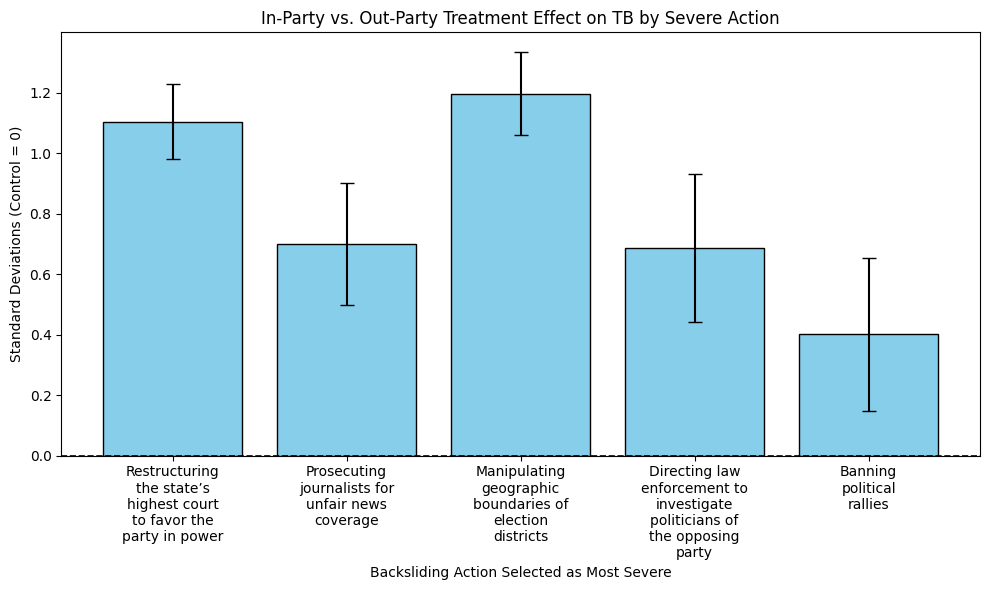

In [242]:
results.graph_delta_ap()
results.graph_delta_tb()
results.plot_hte_in_vs_out(outcome='AP', attr='hte_models')
results.plot_hte_in_vs_out(outcome='TB', attr='hte_models')
results.plot_hte_in_vs_out(outcome='AP', attr='inparty_models')
results.plot_hte_in_vs_out(outcome='TB', attr='inparty_models')
results.plot_hte_in_vs_out(outcome='AP', attr='strength_models')
results.plot_hte_in_vs_out(outcome='TB', attr='strength_models')
results.plot_action_models_bar()


In [243]:
results.print_descriptives()

=== CELL SIZES ===
Treat_Frame  Control  Democracy  Electoral  Policy   All
Treat_Party                                             
Control          678          0          1       0   679
InParty            0        351        374     338  1063
OutParty           0        332        308     338   978
All              678        683        683     676  2720

=== ACTION SELECTED AS MOST SEVERE ===
Q-DemThreat
Restructuring the state’s highest court to favor the party in power           1020
Manipulating geographic boundaries of election districts                       865
Prosecuting journalists for unfair news coverage                               338
Directing law enforcement to investigate politicians of the opposing party     287
Banning political rallies                                                      210
Name: count, dtype: int64

=== ACTION × TREATMENT (balance check) ===
Treat_Party                                         Control  InParty  OutParty
Q-DemThreat            

In [244]:
#hte tests
results.print_all_hte()


HTE by Self-Reported Party

  Democrat (n=1203)
    Any treatment (AP): effect=0.033, p=0.608
    Any treatment (TB): effect=-0.520, p=0.000
    In vs Out party (AP): effect=-0.136, p=0.036
    In vs Out party (TB): effect=1.388, p=0.000

  Republican (n=681)
    Any treatment (AP): effect=0.079, p=0.275
    Any treatment (TB): effect=-0.559, p=0.000
    In vs Out party (AP): effect=-0.190, p=0.008
    In vs Out party (TB): effect=0.843, p=0.000

  Independent (n=755)
    Any treatment (AP): effect=0.104, p=0.269
    Any treatment (TB): effect=-0.766, p=0.000
    In vs Out party (AP): effect=-0.272, p=0.002
    In vs Out party (TB): effect=0.595, p=0.000

HTE by Assigned In-Party

  Democratic (n=1721)
    Any treatment (AP): effect=0.088, p=0.079
    Any treatment (TB): effect=-0.597, p=0.000
    In vs Out party (AP): effect=-0.200, p=0.000
    In vs Out party (TB): effect=1.204, p=0.000

  Republican (n=999)
    Any treatment (AP): effect=0.055, p=0.398
    Any treatment (TB): effec

/tmp/ipykernel_5542/1061060649.py:314: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"    {k}: effect={float(t.effect):.3f}, p={float(t.pvalue):.3f}")
